In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [23]:
# Load data
df = pd.read_csv('customer_transactions.csv')

In [25]:
# Data Preparation
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'])
analysis_date = df['Transaction_Date'].max()

print("=== CUSTOMER SEGMENTATION ANALYSIS ===")
print(f"Total Transactions: {len(df):,}")
print(f"Unique Customers: {df['Customer_ID'].nunique():,}")

=== CUSTOMER SEGMENTATION ANALYSIS ===
Total Transactions: 100,000
Unique Customers: 14,985


In [27]:
# RFM Calculation
rfm = df.groupby('Customer_ID').agg({
    'Transaction_Date': lambda x: (analysis_date - x.max()).days,  # Recency
    'Transaction_ID': 'count',  # Frequency
    'Amount': 'sum'  # Monetary
}).reset_index()

rfm.columns = ['Customer_ID', 'Recency', 'Frequency', 'Monetary']

In [29]:
# Scoring (1-5, 5 is best)
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1], duplicates='drop')
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5], duplicates='drop')
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5], duplicates='drop')

In [31]:
# Convert to numeric
rfm['R_Score'] = rfm['R_Score'].astype(int)
rfm['F_Score'] = rfm['F_Score'].astype(int)
rfm['M_Score'] = rfm['M_Score'].astype(int)
rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

In [33]:
# Segmentation
def segment_customer(score):
    if score >= 12: return 'Champions'
    elif score >= 9: return 'Loyal'
    elif score >= 6: return 'At Risk'
    else: return 'Churn Risk'

rfm['Segment'] = rfm['RFM_Score'].apply(segment_customer)

In [35]:
# Churn Risk Identification (Top 20%)
churn_threshold = rfm['RFM_Score'].quantile(0.20)
rfm['Churn_Risk'] = (rfm['RFM_Score'] <= churn_threshold).astype(int)

print("\n=== SEGMENTATION RESULTS ===")
print(rfm['Segment'].value_counts())
print(f"\nChurn Risk Customers (Top 20%): {rfm['Churn_Risk'].sum():,} ({rfm['Churn_Risk'].sum()/len(rfm)*100:.1f}%)")


=== SEGMENTATION RESULTS ===
Segment
Loyal         4241
Champions     4077
At Risk       3900
Churn Risk    2767
Name: count, dtype: int64

Churn Risk Customers (Top 20%): 3,931 (26.2%)


In [37]:
# Key Metrics by Segment
segment_metrics = rfm.groupby('Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'Customer_ID': 'count'
}).round(2)
segment_metrics.columns = ['Avg_Recency_Days', 'Avg_Frequency', 'Avg_Monetary', 'Customer_Count']
print("\n=== SEGMENT METRICS ===")
print(segment_metrics.sort_values('Avg_Monetary', ascending=False))


=== SEGMENT METRICS ===
            Avg_Recency_Days  Avg_Frequency  Avg_Monetary  Customer_Count
Segment                                                                  
Champions              58.82           9.52       5041.21            4077
Loyal                 115.68           7.14       3627.16            4241
At Risk               161.77           5.36       2597.27            3900
Churn Risk            339.10           3.61       1693.30            2767



✅ Visualization saved as 'customer_segmentation_analysis.png'


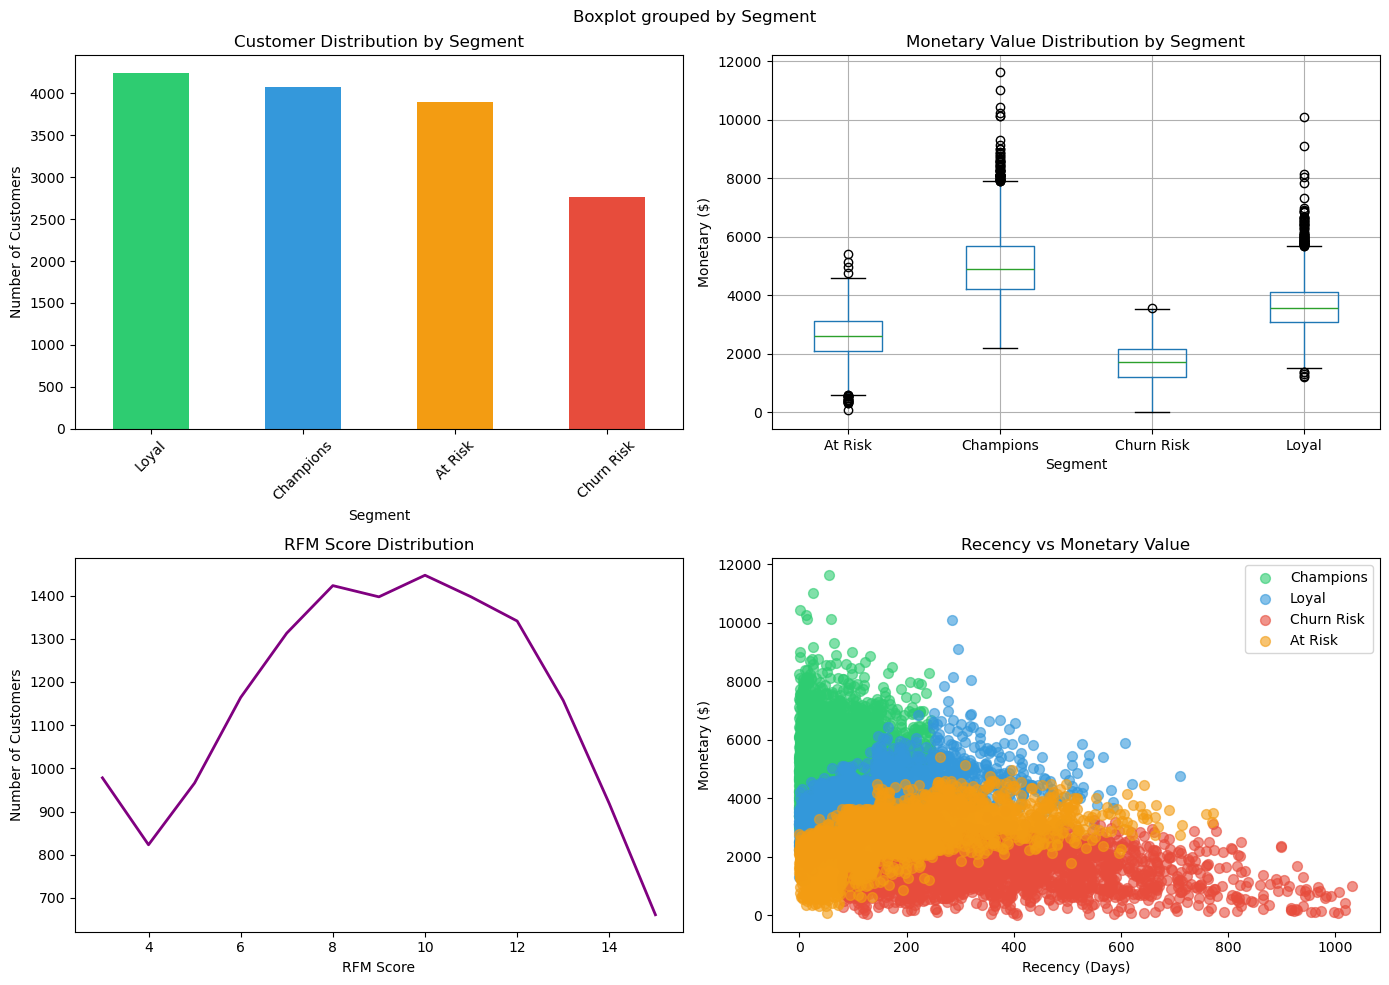

In [43]:
# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Customer Distribution by Segment
ax1 = axes[0, 0]
segment_counts = rfm['Segment'].value_counts()
segment_counts.plot(kind='bar', ax=ax1, color=['#2ecc71', '#3498db', '#f39c12', '#e74c3c'])
ax1.set_title('Customer Distribution by Segment')
ax1.set_ylabel('Number of Customers')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)

# Plot 2: Monetary Value by Segment
ax2 = axes[0, 1]
rfm.boxplot(column='Monetary', by='Segment', ax=ax2)
ax2.set_title('Monetary Value Distribution by Segment')
ax2.set_ylabel('Monetary ($)')
# Plot 3: RFM Score Distribution
ax3 = axes[1, 0]
rfm.groupby('RFM_Score').size().plot(kind='line', ax=ax3, color='purple', linewidth=2)
ax3.set_title('RFM Score Distribution')
ax3.set_ylabel('Number of Customers')
ax3.set_xlabel('RFM Score')

# Plot 4: Recency vs Monetary (Scatter)
ax4 = axes[1, 1]
segments_colors = {'Champions': '#2ecc71', 'Loyal': '#3498db', 'At Risk': '#f39c12', 'Churn Risk': '#e74c3c'}
for segment in rfm['Segment'].unique():
    segment_data = rfm[rfm['Segment'] == segment]
    ax4.scatter(segment_data['Recency'], segment_data['Monetary'], 
               label=segment, alpha=0.6, s=50, color=segments_colors.get(segment, 'gray'))
ax4.set_title('Recency vs Monetary Value')
ax4.set_xlabel('Recency (Days)')
ax4.set_ylabel('Monetary ($)')
ax4.legend()

plt.tight_layout()
plt.savefig('customer_segmentation_analysis.png', dpi=300, bbox_inches='tight')
print("\n✅ Visualization saved as 'customer_segmentation_analysis.png'")

In [45]:
# Export results
rfm.to_csv('rfm_segmentation_results.csv', index=False)
print("✅ RFM analysis exported to 'rfm_segmentation_results.csv'")

✅ RFM analysis exported to 'rfm_segmentation_results.csv'
